<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center><font size=10>Artificial Intelligence and Machine Learning</center></font></h1>



<center> <font size=6> Project Python Foundations: FoodHub Data Analysis

<center><img src="https://www.netsolutions.com/wp-content/uploads/2022/10/essential-features-of-building-an-on-demand-food-ordering-app.jpg" width="720"></center>


### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [ ]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Write your code here to read the data
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/FoodHub/foodhub_order.csv')

In [ ]:
# Write your code here to view the first 5 rows
data.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
print("There are", data.shape[0], 'rows and', data.shape[1], "columns.")

There are 1898 rows and 9 columns.


#### Observations:

* The dataset contains 1,898 records, which is a solid sample size for performing meaningful analysis and drawing reliable insights.
* With 9 columns, the dataset is relatively compact, making it manageable while still capturing multiple dimensions (e.g., cost, time, ratings, cuisine, etc.).
* The structure suggests a well-balanced dataset suitable for both univariate and multivariate analysis without being overly complex.


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:

* The dataset contains a mix of numerical (int64, float64) and categorical (object) variables, enabling both quantitative and categorical analysis.
* Columns like order_id and customer_id are integers and likely represent identifiers, not analytical variables.
* cost_of_the_order is the only continuous numerical (float) variable, suitable for financial analysis.
* Time-related columns (food_preparation_time, delivery_time) are integer-based numerical features, useful for performance analysis.
* Several columns (restaurant_name, cuisine_type, day_of_the_week) are categorical (object) and can be used for grouping and segmentation.
* The rating column is stored as object due to values like "Not given", even though it represents numeric data. It should be cleaned (convert "Not given" to NaN and cast to numeric) for proper analysis.


In [ ]:
# let's see the unique values in the rating column
data['rating'].unique()

array(['Not given', '5', '3', '4'], dtype=object)

In [ ]:
# let's see how much missing rating 'Not given' we have in the data
data['rating'].value_counts(normalize=True)

,proportion
rating,
Not given,0.387777
5,0.309800
4,0.203372
3,0.099052


In [ ]:
# let's copy the original data, so we can keep the main data ad used it later
new_data = data.copy()

In [ ]:
# let's use nan instead of 'Not given'
new_data['rating'] = new_data['rating'].replace('Not given', np.nan)

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
new_data.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,736
food_preparation_time,0
delivery_time,0


In [ ]:
# let's see the different values in the rating column and identify possible outliers
new_data["rating"].value_counts(dropna=False)

,count
rating,
NaN,736
5,588
4,386
3,188


In [ ]:
# let's convert the rating column values to type float, so we can use it as numeric values instead of object
new_data["rating"] = new_data["rating"].astype(float)

In [ ]:
# let's get the restaurant_name and cuisine_type groups having NaN and not NaN values
filtered_groups = new_data.groupby(['restaurant_name', 'cuisine_type']).filter(lambda g: g['rating'].isna().any() and g['rating'].notna().any())
filtered_groups.groupby(['restaurant_name', 'cuisine_type'])['rating'].value_counts(dropna=False)

restaurant_name   cuisine_type    rating
12 Chairs         Middle Eastern  NaN       2
                                  4.0       1
                                  5.0       1
5 Napkin Burger   American        NaN       3
                                  3.0       1
                                           ..
ilili Restaurant  Middle Eastern  5.0       4
                                  3.0       2
indikitch         Indian          NaN       2
                                  4.0       1
                                  5.0       1
Name: count, Length: 347, dtype: int64

In [ ]:
# there are restaurant_name and cuisine_type combinations with NaN and not NaN values, so let's fill the missing rating values for those
group_means = new_data.groupby(['restaurant_name', 'cuisine_type'])['rating'].transform('mean')
new_data['rating'] = new_data['rating'].fillna(group_means)

In [ ]:
# let's review if we still have restaurant_name / cuisine_type combinations with no ratings at all
filtered_groups = new_data.groupby(['restaurant_name', 'cuisine_type']).filter(lambda g: g['rating'].isna().any() and not g['rating'].notna().any())
filtered_groups.groupby(['restaurant_name', 'cuisine_type'])['rating'].value_counts(dropna=False)

,,,count
restaurant_name,cuisine_type,rating,
Alidoro,American,NaN,1
Aurora,Italian,NaN,2
Big Wong Restaurant _¤¾Ñ¼,Chinese,NaN,1
Bistango,Italian,NaN,2
Coppola's East,Italian,NaN,1
Crema Restaurante,Mexican,NaN,1
Emporio,Italian,NaN,1
Friend of a Farmer,American,NaN,3
Gaia Italian Cafe,Italian,NaN,1


In [ ]:
# let's find out if all restaurants still having values with no rating also have records with rating values
filtered_groups.loc[filtered_groups['rating'].isnull()==False, 'restaurant_name']

,restaurant_name


In [ ]:
# replacing the remaining NaN rating values based on the restaurant doesn't make sense, so we'll use a global rating value instead
global_mean = new_data['rating'].mean()
new_data['rating'] = new_data['rating'].fillna(global_mean)

In [ ]:
# let's confirm we don't have missing rating values anymore
new_data[new_data['rating'].isnull()==True].shape

(0, 9)

In [ ]:
# let's now convert the rating values from float to regular rating integer values
new_data['rating'] = new_data['rating'].round().astype(int)
new_data['rating'].value_counts(dropna=False)

,count
rating,
4,927
5,775
3,196


#### Observations:

* Approximately 39% of the rating data is missing.
* There are no significant outliers in the rating column, so imputing missing values using the mean is a reasonable approach.
* We first filled missing ratings using the mean grouped by the restaurant_name and cuisine_type combination. For the remaining missing values—primarily from restaurants with no available ratings—we applied the overall (global) mean.


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
statistical_summary = new_data.describe(include='all').T
statistical_summary

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,1898.0,NaN,NaN,NaN,1477495.5,548.049724,1476547.0,1477021.25,1477495.5,1477969.75,1478444.0
customer_id,1898.0,NaN,NaN,NaN,171168.478398,113698.139743,1311.0,77787.75,128600.0,270525.0,405334.0
restaurant_name,1898,178,Shake Shack,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cuisine_type,1898,14,American,584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cost_of_the_order,1898.0,NaN,NaN,NaN,16.498851,7.483812,4.47,12.08,14.14,22.2975,35.41
day_of_the_week,1898,2,Weekend,1351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,1898.0,NaN,NaN,NaN,4.305058,0.64711,3.0,4.0,4.0,5.0,5.0
food_preparation_time,1898.0,NaN,NaN,NaN,27.37197,4.632481,20.0,23.0,27.0,31.0,35.0
delivery_time,1898.0,NaN,NaN,NaN,24.161749,4.972637,15.0,20.0,25.0,28.0,33.0


In [ ]:
# get the food_preparation_time data from the statistical_summary data frame
min = round(statistical_summary.loc['food_preparation_time']['min'])
average = round(statistical_summary.loc['food_preparation_time']['mean'])
max = round(statistical_summary.loc['food_preparation_time']['max'])

In [ ]:
print("The time it takes for the food to be prepared is:\n", "\n", "Minimum time", min, "minutes", "\n", "Average time", average, "minutes", "\n", "Maximum time", max, "minutes")

The time it takes for the food to be prepared is:
 
 Minimum time 20 minutes 
 Average time 27 minutes 
 Maximum time 35 minutes


#### Observations:

* The food preparation time ranges from 20 to 35 minutes, with an average of approximately 27 minutes, indicating relatively consistent preparation times across orders.
* The interquartile range (23–31 minutes) suggests that most orders are prepared within a narrow window, showing low variability and stable kitchen performance.
* The absence of extreme outliers implies that preparation time is well-controlled and predictable, which is beneficial for customer experience.
* The delivery time ranges from 15 to 33 minutes, with an average of ~24 minutes, showing relatively efficient delivery operations with moderate variability.
* The average rating is ~4.3, with most ratings between 4 and 5, indicating high overall customer satisfaction.
* From the broader summary, American cuisine and Shake Shack dominate in frequency, indicating high demand concentration.
* Additionally, weekend orders are significantly higher than weekday orders.


### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
not_rated_orders = data[data['rating']=='Not given'].shape[0]
print(not_rated_orders, "orders are not rated.")

736 orders are not rated.


#### Observations:

* Out of 1,898 total orders, 736 orders are not rated, which represents a significant portion (~39%) of the dataset.
* This high percentage of missing ratings may introduce bias in customer satisfaction analysis, as conclusions are based on less than two-thirds of the data.
* The presence of many “Not given” values suggests that customers are not consistently providing feedback, which could limit the reliability of rating-based insights.
* This also explains why the rating column is stored as an object type, reinforcing the need for data cleaning (e.g., converting “Not given” to NaN).
* From a business perspective, this indicates an opportunity to improve feedback collection strategies (e.g., incentives, reminders) to gain more complete customer insights.


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

#### **Observations on restaurants orders volume**

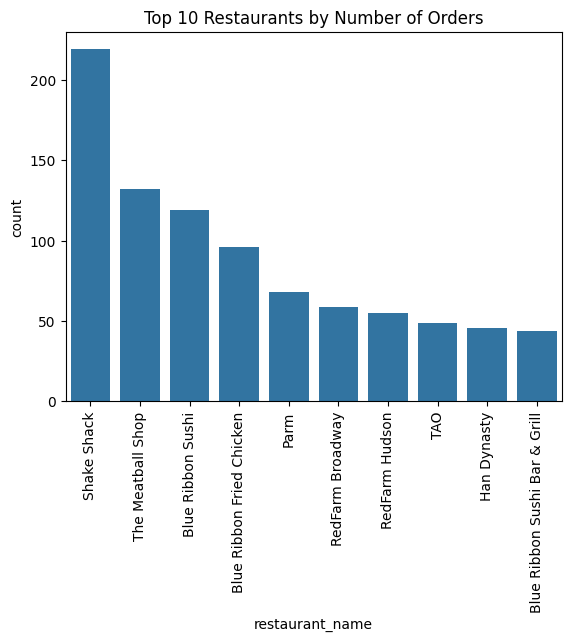

In [ ]:
# let's get the top restaurants with more orders
head_restaurants = new_data['restaurant_name'].value_counts().head(10).index

sns.countplot(data=new_data[new_data['restaurant_name'].isin(head_restaurants)], x='restaurant_name', order=head_restaurants)
plt.xticks(rotation=90)
plt.title('Top 10 Restaurants by Number of Orders')
plt.show()

#### Observations:

* Shake Shack is the clear market leader, with the highest number of orders, significantly outperforming all other restaurants.
* There is a noticeable gap between the first and second-ranked restaurants, indicating that demand is highly concentrated in a few top performers.
* Restaurants like The Meatball Shop and Blue Ribbon Sushi also show strong demand but still fall well below Shake Shack.
* The distribution of orders among the top 10 restaurants is right-skewed, with a sharp drop after the top few, suggesting a long-tail pattern.
* Most restaurants in the top 10 have moderate but similar order volumes, indicating a competitive mid-tier group.
* This pattern suggests that customer preference is heavily influenced by a few popular brands, while the rest share the remaining demand.

#### **Observations on cuisine type orders volume**

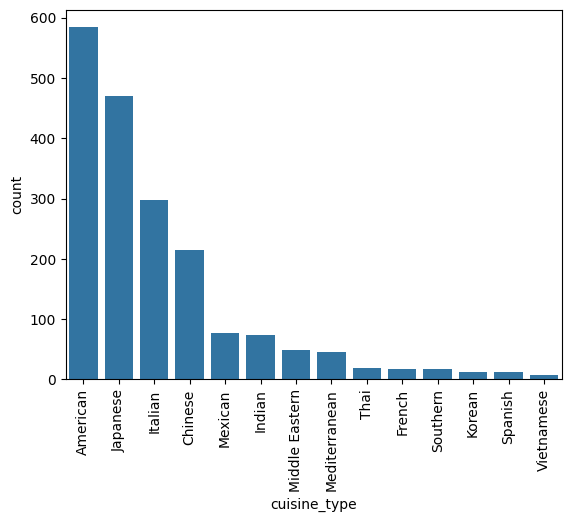

In [ ]:
order = new_data['cuisine_type'].value_counts().index
sns.countplot(data=new_data, x='cuisine_type', order=order)
plt.xticks(rotation=90)
plt.show()

#### Observations:

* American cuisine clearly dominates, with a significantly higher number of orders than any other cuisine, making it the primary driver of demand.
* Japanese cuisine is the second most popular, followed by Italian and Chinese, forming a strong top-tier group.
* The top 4 cuisines (American, Japanese, Italian, and Chinese) account for a large majority of total orders, indicating a strong concentration of customer preferences.
* There is a steep drop in order volume after the top cuisines, suggesting a long-tail distribution where many cuisines have relatively low demand.
* Mid-tier cuisines like Mexican, Indian, and Middle Eastern have moderate but significantly lower order volumes compared to the top group.
* Several cuisines (e.g., Korean, Spanish, Vietnamese) have very low order counts, indicating niche or less popular segments.
* Overall, the distribution shows that customer demand is highly concentrated in a few cuisine types, while the rest contribute marginally.

#### **Observations on day of the week orders volume**

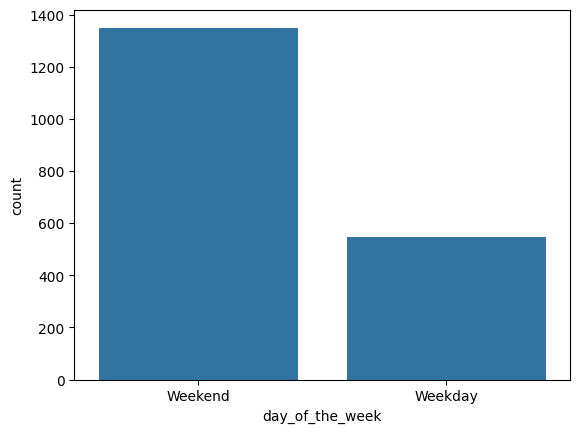

In [ ]:
sns.countplot(data=new_data, x='day_of_the_week')
plt.show()

#### Observations:

* Order volume is significantly higher on weekends, clearly dominating weekday activity.
* Weekend orders are more than twice the number of weekday orders, indicating a strong shift in customer behavior.
* This suggests that customer demand peaks during weekends, likely due to more free time, social activities, or reduced willingness to cook.
* Weekday demand is substantially lower but still consistent, representing a stable baseline of orders.
* The distribution highlights a clear temporal imbalance, where business performance is heavily dependent on weekend demand.

#### **Observations on ratings with and without imputing the missing (Not given) values**

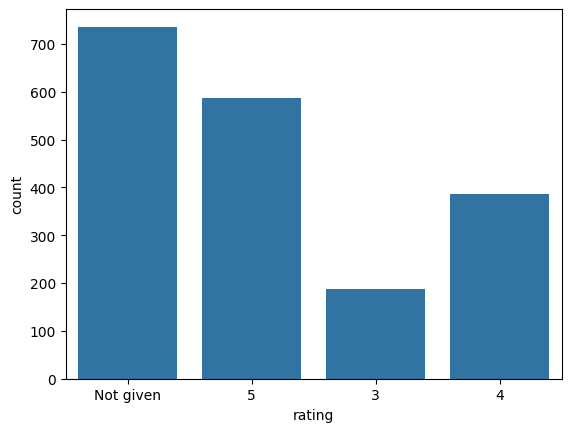

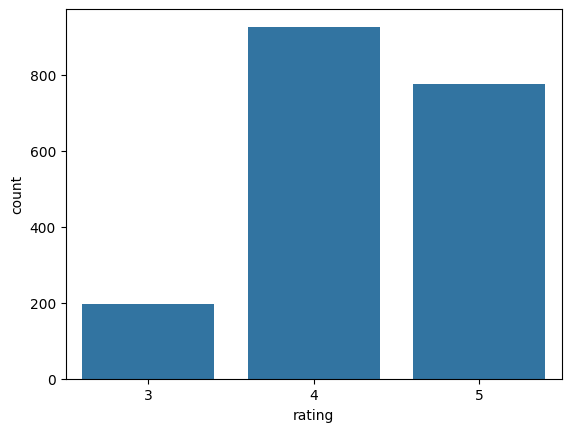

In [ ]:
sns.countplot(data=data, x='rating')
plt.show()

sns.countplot(data=new_data, x='rating')
plt.show()

#### Observations:

* A large proportion of orders are not rated, indicating a significant amount of missing feedback in the dataset.
* Among the available ratings, rating 5 is the most frequent, followed by rating 4, while rating 3 is the least common, suggesting generally high customer satisfaction.
* After imputing missing values, the distribution shifts noticeably, with rating 4 becoming the most dominant category, followed by rating 5.
* The imputation process reduces the variability of ratings, concentrating values around the mean and potentially masking true customer sentiment.
* This highlights that imputed data may introduce bias, making the dataset appear more neutral (centered around 4) than it actually is.

#### **Observations on cost of the orders**

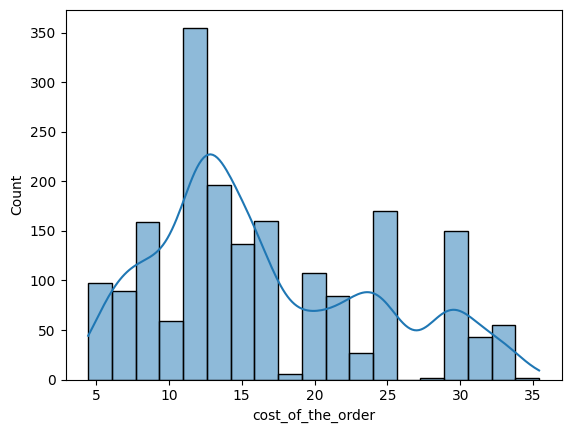

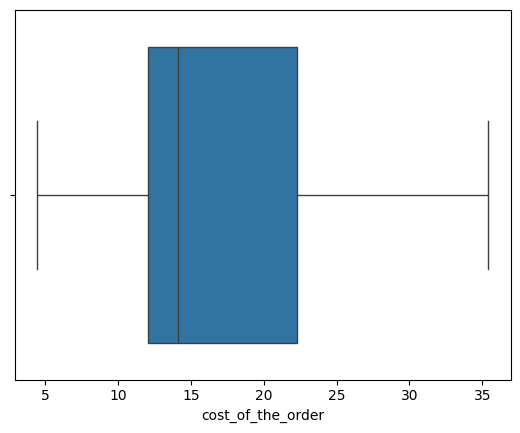

In [ ]:
sns.histplot(data=new_data, x='cost_of_the_order', kde=True)
plt.show()
sns.boxplot(data=new_data,x='cost_of_the_order')
plt.show()

#### Observations:

* The distribution of order cost is right-skewed, with the majority of orders concentrated in the 10 - 20 range, indicating that most customers prefer mid-priced meals.
* The median cost is around 14, and the interquartile range (IQR) spans approximately 12 to 22, showing that 50% of orders fall within this range.
* There is a long right tail extending up to ~$35, suggesting the presence of higher-value orders, although they occur less frequently.
* While no extreme outliers are evident, the upper range indicates occasional premium or bulk orders.
* Overall, the distribution reflects moderate variability, with a strong concentration in mid-range pricing and fewer high-cost transactions.








#### **Observations on food preparation time**

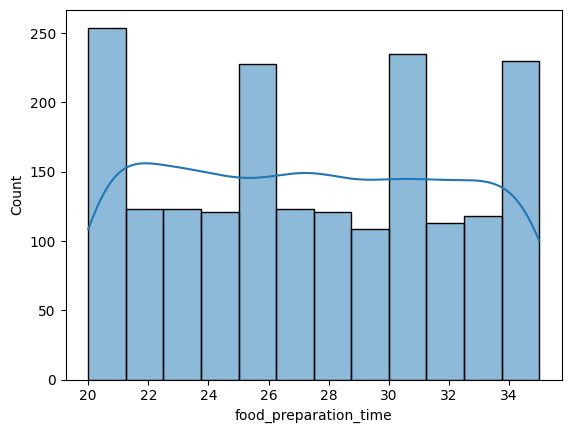

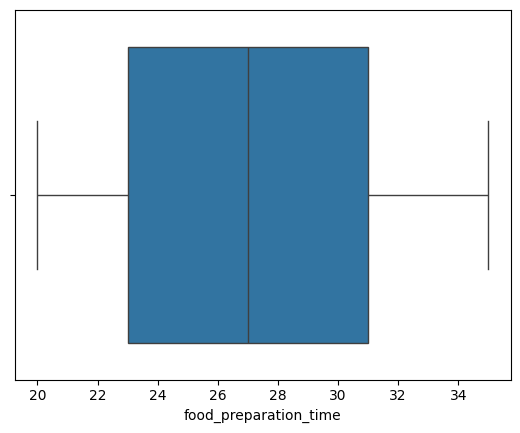

In [ ]:
sns.histplot(data=new_data, x='food_preparation_time', kde=True)
plt.show()
sns.boxplot(data=new_data,x='food_preparation_time')
plt.show()

#### Observations:

* The distribution of food preparation time appears to be approximately uniform to slightly symmetric, with no strong skewness.
* Preparation times range from about 20 to 35 minutes, indicating moderate variability.
* The median is around 27 minutes, suggesting a typical preparation time in the high 20s.
* The middle 50% of values (IQR) lies roughly between 23 and 31 minutes.
* There are no significant outliers, as the data is fairly evenly spread across the range.
* Overall, preparation times are consistently distributed, with no extreme concentrations or anomalies.

#### **Observations on delivery time**

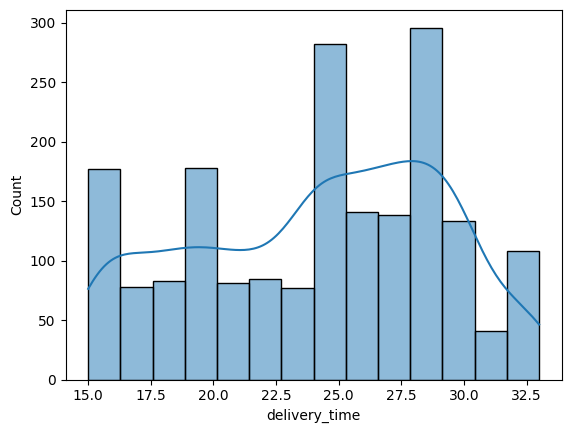

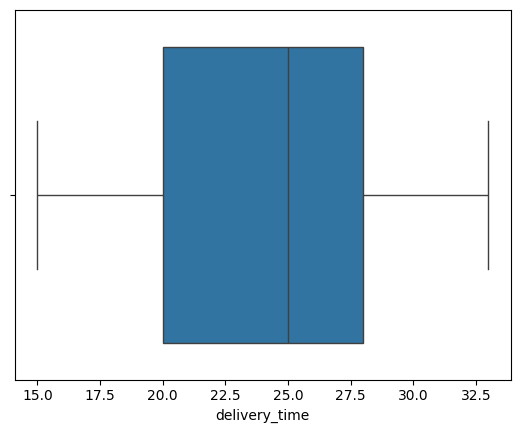

In [ ]:
sns.histplot(data=new_data, x='delivery_time', kde=True)
plt.show()
sns.boxplot(data=new_data,x='delivery_time')
plt.show()

In [ ]:
skewness = new_data['delivery_time'].skew()
print(f"Skewness of delivery time: {skewness:.3f}")

Skewness of delivery time: -0.237


#### Observations:

* The distribution of delivery time is approximately symmetric with a slight left skew, as indicated by a small negative skewness value (-0.237).
* Delivery times range from about 15 to 33 minutes, showing moderate variability.
* The median delivery time is around 25 minutes, suggesting that most deliveries are completed in the mid-20s.
* The middle 50% of values (IQR) lies approximately between 20 and 28 minutes, indicating consistent delivery performance.
* There are no significant outliers, and most values are concentrated between 20 and 30 minutes.
* Overall, delivery times are relatively stable, with a slight tendency toward faster deliveries rather than longer delays.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
new_data['restaurant_name'].value_counts().head()

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:

* The top five restaurants by number of orders are Shake Shack (219), The Meatball Shop (132), Blue Ribbon Sushi (119), Blue Ribbon Fried Chicken (96), and Parm (68).
* Shake Shack clearly dominates in order volume, receiving significantly more orders than any other restaurant.
* There is a gradual decline in order volume from the top-ranked restaurant to the fifth, indicating a skewed distribution where a few restaurants capture a large share of demand.
* The presence of multiple “Blue Ribbon” branded restaurants in the top five suggests strong brand recognition and customer preference for that group.
* Overall, demand is concentrated among a small number of high-performing restaurants, while the remaining restaurants likely have much lower order volumes.

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

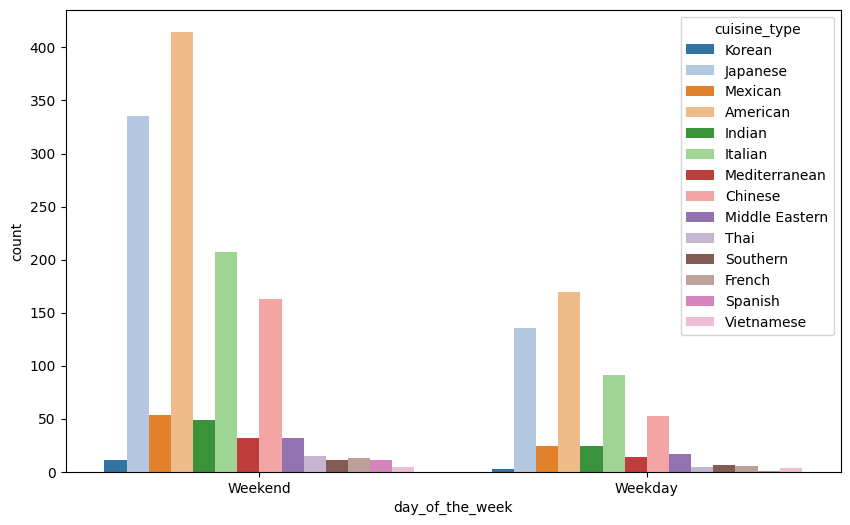

,count
cuisine_type,
American,415


In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=new_data, x='day_of_the_week', hue='cuisine_type', palette='tab20')
plt.show()

new_data[new_data['day_of_the_week']=='Weekend']['cuisine_type'].value_counts().head(1)

#### Observations:

* The most popular cuisine on weekends is American cuisine, with 415 orders, making it the clear leader.
* American cuisine also remains the most popular on weekdays, indicating consistent dominance across the week.
* Japanese cuisine is the second most popular, followed by Italian and Chinese cuisines, showing a clear preference for a few major cuisine types.
* Order volumes for most cuisines are significantly higher on weekends than weekdays, suggesting increased overall demand during weekends rather than a change in cuisine preference.
* Lower-demand cuisines (e.g., French, Spanish, Vietnamese) contribute minimally to total orders in both periods, indicating limited customer interest or niche demand.


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
percentage = (len(new_data[new_data['cost_of_the_order']>20])/len(new_data))*100

print(f"Percentage of orders > $20: {percentage:.2f}%")

Percentage of orders > $20: 29.24%


#### Observations:

* Approximately 29.24% of the orders cost more than 20, indicating that nearly one-third of all orders fall into the higher price range.
* The majority of orders (about 70.76%) are priced at 20 or below, suggesting that customers generally prefer lower to mid-range pricing.

### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
mean_delivery_time = new_data['delivery_time'].mean()
median_delivery_time = new_data['delivery_time'].median()

print(f"The average order delivery time is {mean_delivery_time:.2f} minutes while the median is {median_delivery_time:.2f} minutes")

The average order delivery time is 24.16 minutes while the median is 25.00 minutes


#### Observations:

* The average delivery time is approximately 24 minutes, indicating that most orders are fulfilled within a relatively short time frame.
* This suggests an efficient delivery process, as the average aligns well with the overall distribution (generally between 20 and 30 minutes).
* The mean being close to the median (around 25 minutes) indicates that delivery times are fairly consistent with minimal skewness.
* Overall, the delivery system appears reliable and stable, with no significant delays affecting the average performance.


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
top_three_customers = new_data['customer_id'].value_counts().head(3)
top_three_customers

,count
customer_id,
52832,13
47440,10
83287,9


In [ ]:
unique_customers_count = len(new_data['customer_id'].unique())
total_orders = len(new_data)
average_orders_per_customer = total_orders / unique_customers_count

print(f"Average number of orders per customer: {average_orders_per_customer:.2f}")


Average number of orders per customer: 1.58


#### Observations:

* The top 3 most frequent customers are:
  * Customer 52832 with 13 orders
  * Customer 47440 with 10 orders
  * Customer 83287 with 9 orders
* These customers significantly outperform the average, as the average number of orders per customer is only 1.58, indicating that most customers place very few orders.
* The top customer (52832) places over 8 times more orders than the average customer, highlighting a small but highly valuable segment of repeat users.
* This suggests that the business follows a long-tail distribution, where a majority of customers are low-frequency users, while a few contribute disproportionately to total orders.
* Providing discount vouchers to these top customers is a highly effective retention strategy, as it targets users who already demonstrate strong engagement and are likely to generate continued revenue.


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


#### **Observations on numerical columns correlation**

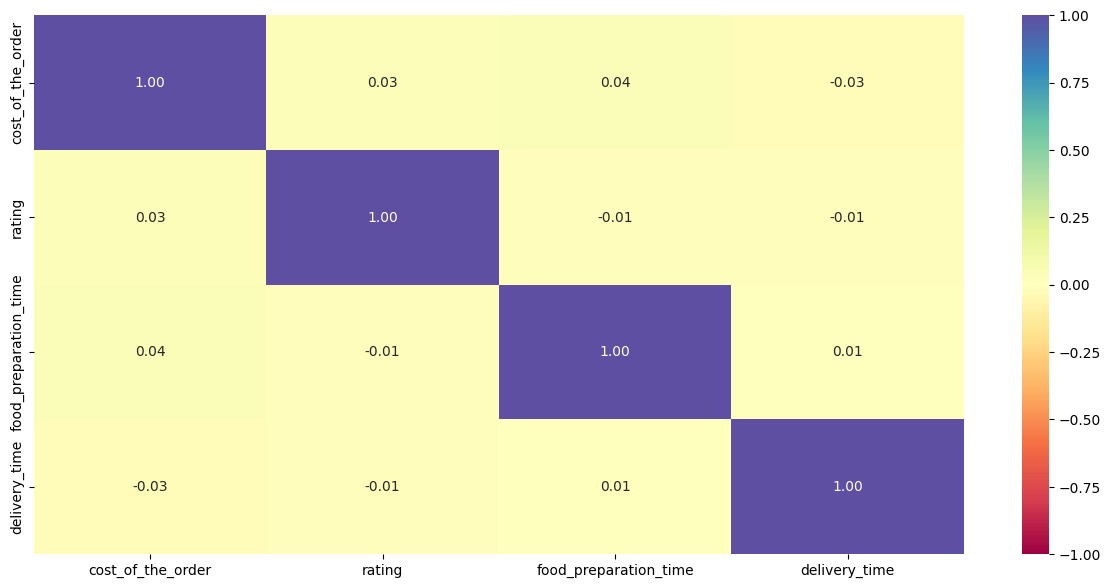

In [ ]:
numerical_columns = ['cost_of_the_order', 'rating', 'food_preparation_time', 'delivery_time']
corr = new_data[numerical_columns].corr()

plt.figure(figsize=(15, 7))
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

#### Observations:

* All numerical variables exhibit very weak or negligible correlations, with coefficients close to zero.
* There is no significant relationship between order cost, preparation time, delivery time, and rating.
* This suggests that these variables are largely independent and do not strongly influence one another.

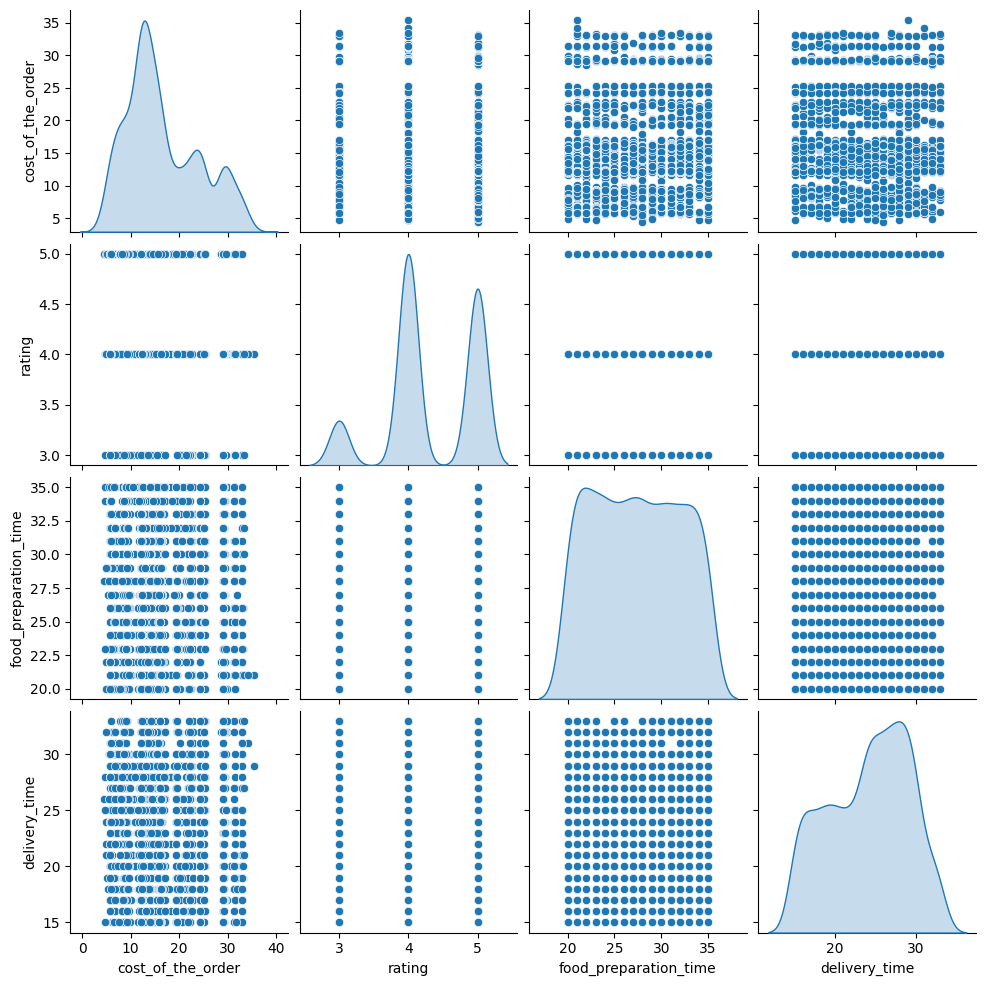

In [ ]:
sns.pairplot(data=new_data[numerical_columns], diag_kind="kde")
plt.show()

#### Observations:

* The pairplot shows no clear relationships between numerical variables, with scatter plots indicating widely dispersed data points.
* Ratings are discrete and concentrated around higher values, while cost and time variables show independent distributions.
* Overall, the variables appear to be largely independent with no strong patterns or trends.

#### **Observations on delivery time per cuisine on weekdends vs weekdays**

---



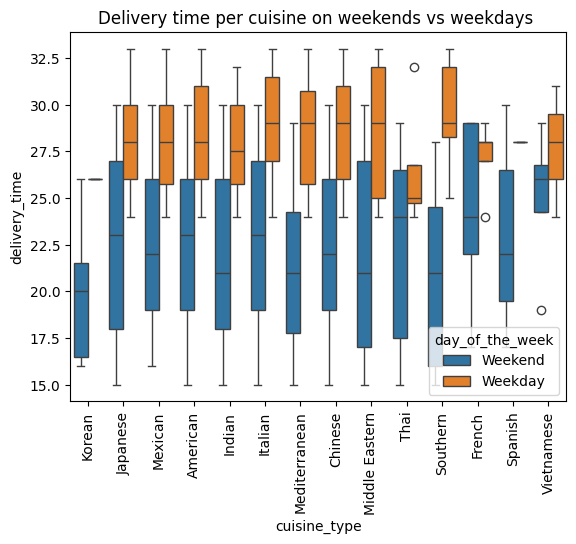

In [ ]:
sns.boxplot(
    data=new_data,
    x='cuisine_type',
    y='delivery_time',
    hue='day_of_the_week'
)

plt.xticks(rotation=90)
plt.title('Delivery time per cuisine on weekends vs weekdays ')
plt.show()

#### Observations:

* Delivery times are generally higher on weekdays than weekends across all cuisines.
* The pattern is consistent, indicating a system-wide effect rather than cuisine-specific differences.
* Most delivery times fall between 20-30 minutes, with moderate variability and no significant outliers.
* Delivery operations appear to be slower during weekdays, likely due to higher traffic, while weekends show relatively faster service across cuisines.

#### **Observations on food preparation time per cuisine on weekdends vs weekdays**

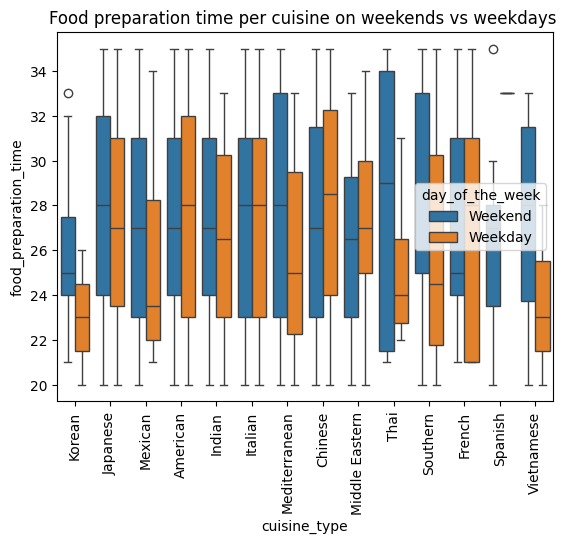

In [ ]:
sns.boxplot(
    data=new_data,
    x='cuisine_type',
    y='food_preparation_time',
    hue='day_of_the_week'
)

plt.xticks(rotation=90)
plt.title('Food preparation time per cuisine on weekends vs weekdays ')
plt.show()

#### Observations:

* Food preparation times are generally higher on weekends than weekdays across most cuisines.
* The pattern is consistent, indicating a system-wide effect rather than cuisine-specific differences.
* Most preparation times fall between 23–30 minutes, with moderate variability and no significant outliers.

#### **Observations on cost of the order per cuisine on weekdends vs weekdays**

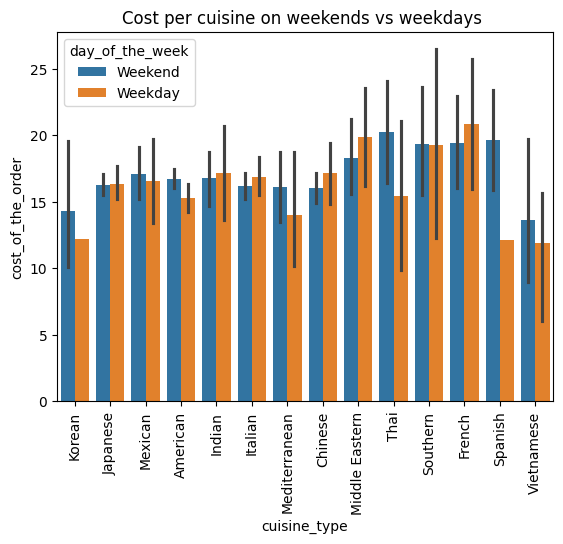

In [ ]:
sns.barplot(
    data=new_data,
    x='cuisine_type',
    y='cost_of_the_order',
    hue='day_of_the_week',
    estimator='mean'
)

plt.xticks(rotation=90)
plt.title('Cost per cuisine on weekends vs weekdays ')
plt.show()

#### Observations:

* The average cost of orders is fairly consistent between weekdays and weekends across cuisines.
* Some cuisines show slightly higher costs on weekends, but differences are minimal overall.
* A few cuisines (e.g., French, Thai, Middle Eastern) tend to have higher average order values regardless of the day.

#### **Observations on cost and time vs rating**

In [ ]:
# let's create a new column to add the total time
new_data['total_time'] = (
    new_data['food_preparation_time'] + new_data['delivery_time']
)

# let's create a new column with the experience score (Higher score = more expensive + slower → potentially worse experience)
new_data['experience_score'] = (
    new_data['cost_of_the_order'] +
    new_data['food_preparation_time'] +
    new_data['delivery_time']
)

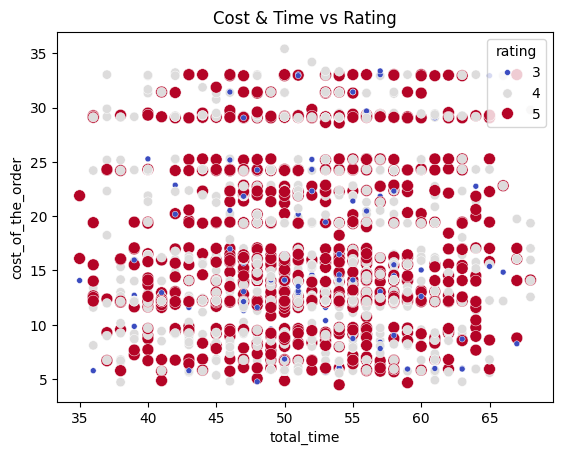

In [ ]:
sns.scatterplot(
    data=new_data,
    x='total_time',
    y='cost_of_the_order',
    hue='rating',
    size='rating',
    palette='coolwarm'
)

plt.title('Cost & Time vs Rating')
plt.show()

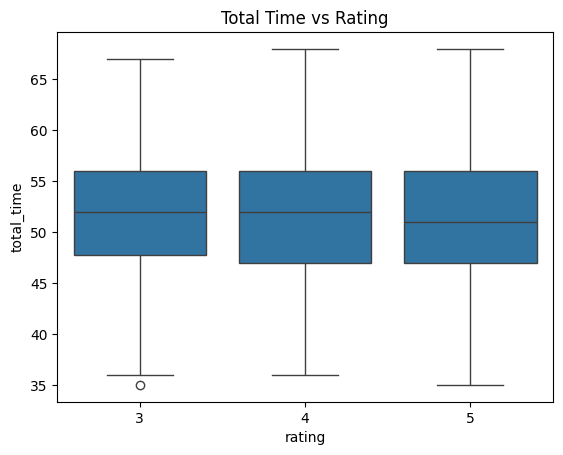

In [ ]:
sns.boxplot(
    data=new_data,
    x='rating',
    y='total_time'
)

plt.title('Total Time vs Rating')
plt.show()

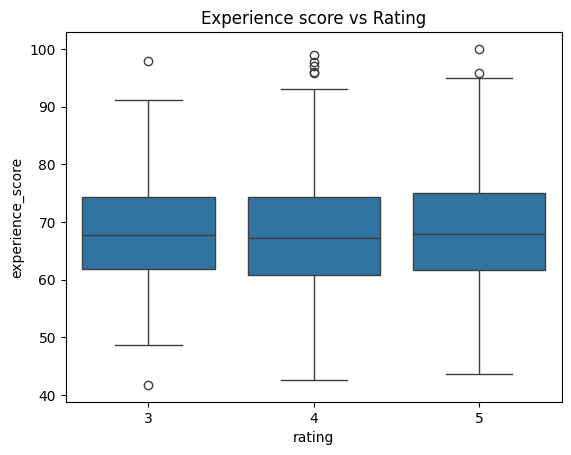

In [ ]:
sns.boxplot(data=new_data, x='rating', y='experience_score')

plt.title('Experience score vs Rating')
plt.show()

#### Observations:

* The combined analysis of cost, preparation time, and delivery time shows no strong relationship with customer ratings.
* Ratings are consistently distributed across all levels of cost and total time, indicating that higher cost or longer durations do not lead to lower satisfaction.
* Even when combining these variables into a single experience score, the distribution remains similar across rating levels.
* This suggests that customer satisfaction is likely influenced by factors beyond cost and time, such as food quality or service experience.

#### **Observations on cuisine type vs rating**

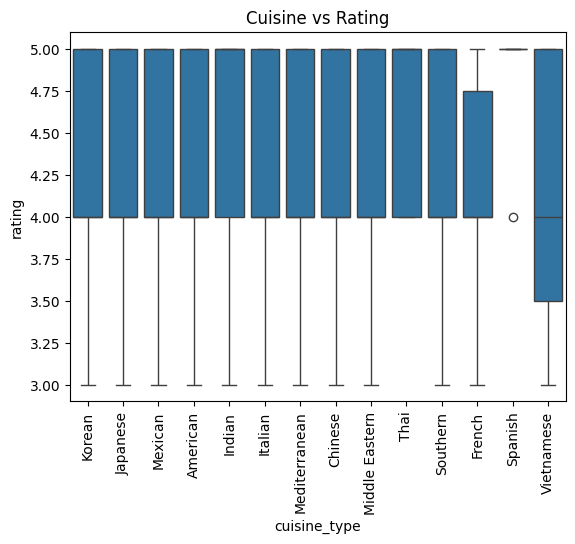

In [ ]:
sns.boxplot(data=new_data, x='cuisine_type', y='rating')

plt.title('Cuisine vs Rating')
plt.xticks(rotation=90)
plt.show()

#### Observations:

* Ratings are consistently high across all cuisines, with most values between 4 and 5.
* There is minimal variation between cuisines, indicating that cuisine type has little impact on customer ratings.
* Overall, customer satisfaction is uniform across different cuisine categories.
* Vietnamese cuisine shows slightly more variability, with a wider spread including some lower ratings.

#### **Observations on cuisine type vs cost**

<Axes: xlabel='cuisine_type'>

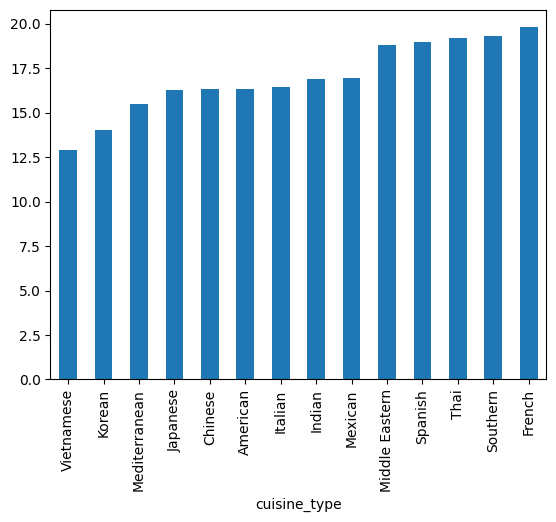

In [ ]:
new_data.groupby('cuisine_type')['cost_of_the_order'].mean().sort_values().plot(kind='bar')

#### Observations:

* The overall difference between the lowest and highest average costs is moderate, suggesting pricing varies but not drastically across cuisines.
* The average cost of orders varies across cuisines, with French, Southern, and Thai cuisines being more expensive, while Vietnamese and Korean cuisines are more affordable.

#### **Observations on top restaurants, cuisine vs rating**

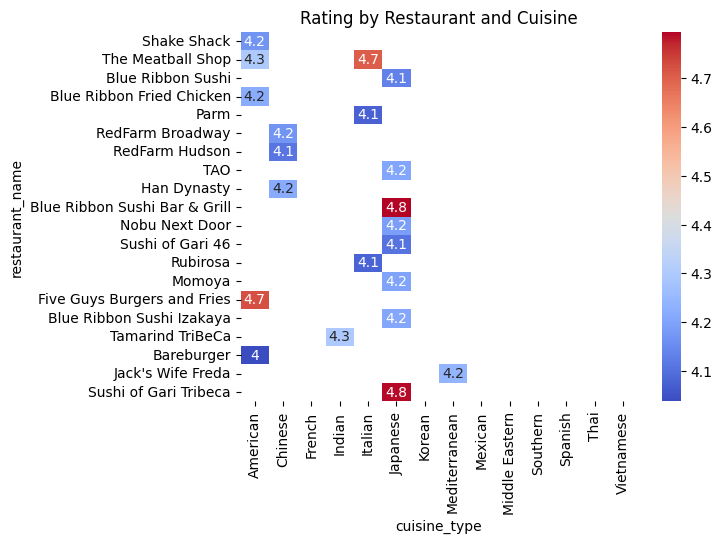

In [ ]:
top_restaurants = new_data['restaurant_name'].value_counts().head(20).index

pivot = new_data.pivot_table(
    values='rating',
    index='restaurant_name',
    columns='cuisine_type',
    aggfunc='mean'
)

# Limit to top restaurants for readability
pivot = pivot.loc[top_restaurants]

sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title('Rating by Restaurant and Cuisine')
plt.show()

#### Observations:

* Ratings among top restaurants are consistently high, typically between 4.0 and 4.8, indicating strong customer satisfaction.
* There is greater variability across restaurants than across cuisines, suggesting that restaurant-specific factors drive ratings more than cuisine type.
* While some restaurants achieve exceptionally high ratings, others within the same cuisine perform at average levels, highlighting differences in service quality and execution.

#### **Observations on top restaurants, cuisine, and orders volume**

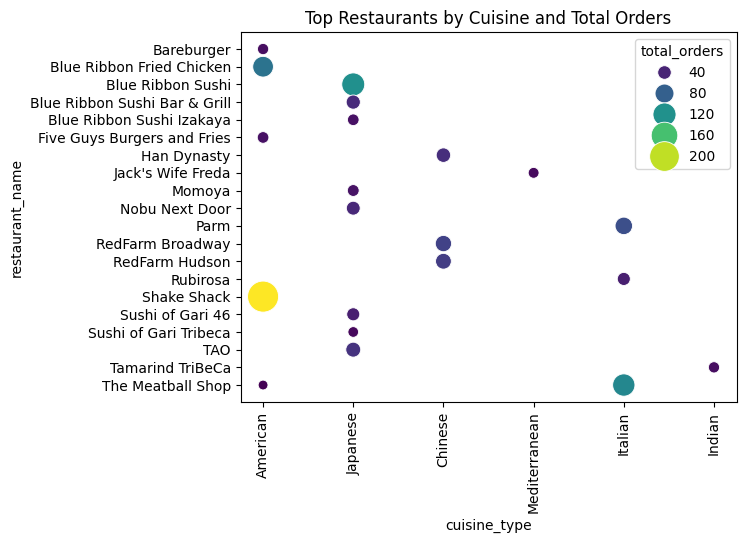

In [ ]:
agg = (
    new_data
    .groupby(['restaurant_name', 'cuisine_type'])
    .size()
    .reset_index(name='total_orders')
)

top_restaurants = new_data['restaurant_name'].value_counts().head(20).index
df_top = agg[agg['restaurant_name'].isin(top_restaurants)]

sns.scatterplot(
    data=df_top,
    x='cuisine_type',
    y='restaurant_name',
    size='total_orders',
    hue='total_orders',
    palette='viridis',
    sizes=(50, 500)
)

plt.xticks(rotation=90)
plt.title('Top Restaurants by Cuisine and Total Orders')
plt.show()

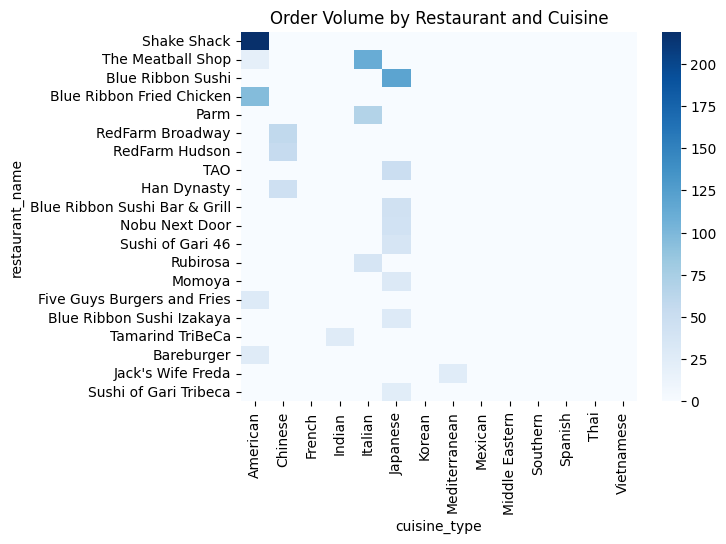

In [ ]:
pivot = new_data.pivot_table(
    index='restaurant_name',
    columns='cuisine_type',
    aggfunc='size',
    fill_value=0
)

pivot = pivot.loc[top_restaurants]

sns.heatmap(pivot, cmap='Blues')
plt.title('Order Volume by Restaurant and Cuisine')
plt.show()

#### Observations:

* Order volume is highly concentrated, with a few restaurants (e.g., Shake Shack) accounting for a large share of total orders.
* American cuisine shows the highest demand, driven by a small number of dominant restaurants.
* Japanese cuisine exhibits more distributed demand across multiple restaurants, while other cuisines show lower or more fragmented order volumes.
* Overall, restaurant-level performance plays a key role in driving demand within each cuisine category.

#### **Observations on cuisine types cost and orders volume**

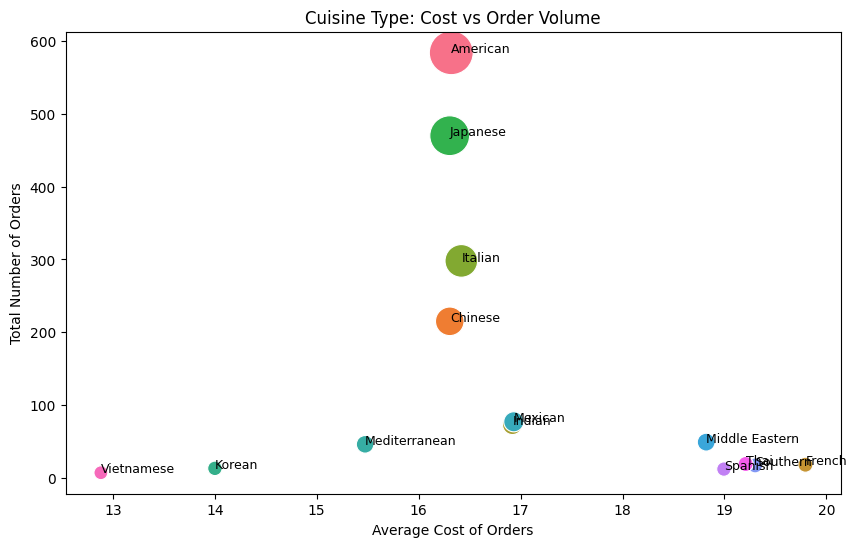

In [ ]:
# Aggregate data at the cuisine level
# We calculate:
# - avg_cost: average cost of orders for each cuisine
# - total_orders: total number of orders for each cuisine
agg = (
    new_data
    .groupby('cuisine_type')
    .agg(
        avg_cost=('cost_of_the_order', 'mean'),     # Average cost per cuisine
        total_orders=('cost_of_the_order', 'count') # Total number of orders (volume)
    )
    .reset_index()  # Convert grouped index back to a column
)

# Create the figure canvas
plt.figure(figsize=(10,6))

# Create a bubble chart (scatter plot with size encoding)
sns.scatterplot(
    data=agg,
    x='avg_cost',          # X-axis → average cost of cuisine
    y='total_orders',      # Y-axis → total number of orders (popularity)
    size='total_orders',   # Bubble size → order volume (bigger = more popular)
    hue='cuisine_type',    # Color → different cuisine categories
    sizes=(100, 1000),     # Control min/max bubble size
    legend=False           # Disable legend to avoid clutter (optional)
)

# Add labels and title for clarity
plt.title('Cuisine Type: Cost vs Order Volume')
plt.xlabel('Average Cost of Orders')
plt.ylabel('Total Number of Orders')

# Annotate each bubble with the cuisine name
for i in range(len(agg)):
    plt.text(
        agg['avg_cost'][i],
        agg['total_orders'][i],
        agg['cuisine_type'][i],
        fontsize=9
    )

# Display the plot
plt.show()

#### Observations:

* American cuisine clearly dominates demand, with the highest number of orders by a significant margin, while maintaining a mid-range average cost (~16 dollars).
* Japanese cuisine is the second most popular, also positioned in the mid-price range, indicating strong demand at moderate pricing.
* Italian and Chinese cuisines show solid but lower demand, suggesting they are popular but not leading categories in the market.
* Most high-volume cuisines cluster around the 15-17 dollars range, indicating that mid-priced offerings drive the majority of orders.
* Higher-cost cuisines (e.g., French, Spanish, Middle Eastern) tend to have significantly lower order volumes, suggesting price sensitivity among customers.
* Lower-cost cuisines (e.g., Vietnamese, Korean) also have low order volumes, which may indicate limited popularity or lower visibility, not just pricing effects.
* There is a clear inverse trend at the extremes:
  * Very high-cost cuisines → low demand
  * Very low-cost cuisines → also low demand
  * Mid-range pricing → highest demand
* Order volume is highly concentrated in a few cuisines, while many others have relatively small shares, indicating a skewed demand distribution.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
# let's make a copy of the original data having "Not given" values in the rating column
df = data.copy()

# Convert to numeric (invalid values like "Not given" → NaN)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

promo_restaurants = (
    df
    .groupby('restaurant_name')
    .agg(
        rating_count=('rating', 'count'),   # counts ONLY valid ratings
        avg_rating=('rating', 'mean')       # mean ignores NaN automatically
    )
    .reset_index()
)

promo_restaurants = promo_restaurants[
    (promo_restaurants['rating_count'] > 50) &
    (promo_restaurants['avg_rating'] > 4)
].sort_values(by='avg_rating', ascending=False)

promo_restaurants

,restaurant_name,rating_count,avg_rating
153,The Meatball Shop,84,4.511905
20,Blue Ribbon Fried Chicken,64,4.328125
136,Shake Shack,133,4.278195
21,Blue Ribbon Sushi,73,4.219178


#### Observations:

* Only four restaurants meet the criteria, indicating that achieving both high rating volume and high average rating is relatively rare.
* The Meatball Shop stands out with the highest average rating, while Shake Shack has the highest number of ratings, reflecting strong popularity.
* The selected restaurants combine high customer satisfaction and strong engagement, making them suitable candidates for promotional offers.


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# Calculate commission per order
new_data['revenue'] = 0.0

new_data.loc[new_data['cost_of_the_order'] > 20, 'revenue'] = new_data['cost_of_the_order'] * 0.25
new_data.loc[(new_data['cost_of_the_order'] > 5) & (new_data['cost_of_the_order'] <= 20), 'revenue'] = new_data['cost_of_the_order'] * 0.15

total_revenue = new_data['revenue'].sum()

print(f"The net revenue generated by the company across all orders is: ${total_revenue:.2f}")


The net revenue generated by the company across all orders is: $6166.30


#### Observations:

* The total net revenue generated by the company is 6,166.30, based on a tiered commission structure.
* Higher-value orders contribute more revenue due to a higher commission rate (25%), while mid-range orders provide steady revenue through volume.
* This pricing strategy allows the company to balance high-margin and high-volume revenue streams.


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
total_orders = len(new_data)

orders_over_60 = new_data[new_data['total_time'] > 60].shape[0]

percentage = (orders_over_60 / total_orders) * 100

print(f"Percentage of orders taking more than 60 minutes: {percentage:.2f}%")

Percentage of orders taking more than 60 minutes: 10.54%


#### Observations:

* The total delivery time was calculated by summing food preparation time and delivery time.
* The percentage of orders taking more than 60 minutes was computed by dividing the number of such orders by the total number of orders.
* The results indicate that only a small proportion of orders exceed 60 minutes, suggesting that most deliveries are completed efficiently within a reasonable timeframe.


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
mean_delivery_time = new_data.groupby('day_of_the_week')['delivery_time'].mean()

weekday_mean = mean_delivery_time['Weekday']
weekend_mean = mean_delivery_time['Weekend']

print(f"Mean delivery time on weekdays: {weekday_mean:.2f} minutes")
print(f"Mean delivery time on weekends: {weekend_mean:.2f} minutes")

Mean delivery time on weekdays: 28.34 minutes
Mean delivery time on weekends: 22.47 minutes


#### Observations:

* The mean delivery time on weekdays is 28.34 minutes, while on weekends it is 22.47 minutes.
* This shows that delivery times are shorter on weekends compared to weekdays, with a difference of approximately 6 minutes.
* This suggests that the delivery process is more efficient during weekends.

##### This could be due to:

* Better staff availability or scheduling on weekends
* More optimized operations during peak demand periods
* Potential weekday constraints such as traffic or limited delivery resources

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:

* Customer satisfaction is generally high and stable, with no strong dependency on cost, delivery time, or cuisine type. This suggests the platform is delivering a consistently acceptable experience across segments.
* Demand is highly concentrated, with a small number of restaurants and cuisines (notably American and Japanese) driving a large share of total orders. This indicates a skewed marketplace where a few players dominate performance.
* Mid-priced cuisines (~15–17 dollars range) achieve the highest order volumes, while both low-cost and high-cost cuisines show lower demand. This reflects customer preference for moderate pricing.
* Restaurant-level performance has a stronger impact than cuisine type alone, meaning brand reputation, quality, and visibility are key drivers of success.
* Delivery operations are more efficient on weekends than weekdays, with significantly lower delivery times (~6 minutes faster), indicating potential operational inefficiencies during weekdays.
* A significant portion of ratings (~39%) is missing, which limits the reliability of customer satisfaction insights and introduces potential bias in analysis.

### Recommendations:

1. Leverage High-Performing Cuisines and Restaurants
  * Prioritize American and Japanese cuisines in marketing campaigns and platform visibility.
  * Promote top-performing restaurants (e.g., featured listings, recommendations) to maximize conversions.
2. Optimize Pricing Strategy
 * Encourage restaurants to align pricing within the high-demand mid-range (15 to 17 dollars).
 * Introduce dynamic pricing or bundles to increase order volume for higher-cost cuisines.
3. Improve Underperforming Segments
  * Support lower-demand cuisines (e.g., Korean, Vietnamese) with:
    * Promotions and discounts
    * Increased visibility in the app
    * Curated recommendations
4. Enhance Customer Feedback Collection
  * Reduce missing ratings by:
    * Offering incentives (discounts, loyalty points)
    * Sending post-delivery reminders
  * More complete data will enable better personalization and decision-making
5. Address Weekday Delivery Inefficiencies
  * Investigate causes of slower weekday delivery (e.g., staffing, logistics, traffic).
  * Optimize:
    * Driver allocation
    * Route planning
    * Peak-hour operations
6. Focus on Customer Retention
  * Since average orders per customer are low (~1.58), implement:
    * Loyalty programs
    * Personalized recommendations
    * Targeted promotions for repeat orders
7. Capitalize on High-Value Orders
  * With ~29% of orders above 20 dollars:
    * Promote premium meal bundles
    * Highlight high-value restaurants
    * Offer upselling strategies (add-ons, combos)

---